In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
absenteeism_at_work = fetch_ucirepo(id=445) 
  
# data (as pandas dataframes) 
X = absenteeism_at_work.data.features 
y = absenteeism_at_work.data.targets 
  
# metadata 
print(absenteeism_at_work.metadata) 
  
# variable information 
print(absenteeism_at_work.variables) 


{'uci_id': 445, 'name': 'Absenteeism at work', 'repository_url': 'https://archive.ics.uci.edu/dataset/445/absenteeism+at+work', 'data_url': 'https://archive.ics.uci.edu/static/public/445/data.csv', 'abstract': 'The database was created with records of absenteeism at work from July 2007 to July 2010 at a courier company in Brazil.', 'area': 'Business', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 740, 'num_features': 19, 'feature_types': ['Integer', 'Real'], 'demographics': ['Age', 'Education Level'], 'target_col': ['Absenteeism time in hours'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2012, 'last_updated': 'Fri Mar 08 2024', 'dataset_doi': '10.24432/C5X882', 'creators': ['Andrea Martiniano', 'Ricardo Ferreira'], 'intro_paper': {'ID': 414, 'type': 'NATIVE', 'title': 'Application of a neuro fuzzy network in prediction of absenteeism at work', 'authors': 'A

In [4]:
# View variable information
variables = absenteeism_at_work.variables.copy()
variables

,name,role,type,demographic,description,units,missing_values
0,ID,ID,Integer,None,None,None,no
1,Reason for absence,Feature,Integer,None,None,None,no
2,Month of absence,Feature,Integer,None,None,None,no
3,Day of the week,Feature,Integer,None,None,None,no
4,Seasons,Feature,Integer,None,None,None,no
5,Transportation expense,Feature,Integer,None,None,None,no
6,Distance from Residence to Work,Feature,Integer,None,None,None,no
7,Service time,Feature,Integer,None,None,None,no
8,Age,Feature,Integer,Age,None,None,no
9,Work load Average/day,Feature,Continuous,None,None,None,no


In [5]:
# Combine features and target into a single DataFrame for easier analysis
# Make sure y is a Series with a clean column name
if isinstance(y, pd.DataFrame):
    target_col = y.columns[0]
    y_series = y[target_col]
else:
    y_series = y
    target_col = "Absenteeism time in hours"

df = X.copy()
df[target_col] = y_series

df.head()

,Reason for absence,Month of absence,Day of the week,Seasons,Transportation expense,Distance from Residence to Work,Service time,Age,Work load Average/day,Hit target,Disciplinary failure,Education,Son,Social drinker,Social smoker,Pet,Weight,Height,Body mass index,Absenteeism time in hours
0,26,7,3,1,289,36,13,33,239.554,97,0,1,2,1,0,1,90,172,30,4
1,0,7,3,1,118,13,18,50,239.554,97,1,1,1,1,0,0,98,178,31,0
2,23,7,4,1,179,51,18,38,239.554,97,0,1,0,1,0,0,89,170,31,2
3,7,7,5,1,279,5,14,39,239.554,97,0,1,2,1,1,0,68,168,24,4
4,23,7,5,1,289,36,13,33,239.554,97,0,1,2,1,0,1,90,172,30,2


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Reason for absence,740.0,19.216216,8.433406,0.000,13.000,23.000,26.000,28.000
Month of absence,740.0,6.324324,3.436287,0.000,3.000,6.000,9.000,12.000
Day of the week,740.0,3.914865,1.421675,2.000,3.000,4.000,5.000,6.000
Seasons,740.0,2.544595,1.111831,1.000,2.000,3.000,4.000,4.000
Transportation expense,740.0,221.329730,66.952223,118.000,179.000,225.000,260.000,388.000
Distance from Residence to Work,740.0,29.631081,14.836788,5.000,16.000,26.000,50.000,52.000
Service time,740.0,12.554054,4.384873,1.000,9.000,13.000,16.000,29.000
Age,740.0,36.450000,6.478772,27.000,31.000,37.000,40.000,58.000
Work load Average/day,740.0,271.490235,39.058116,205.917,244.387,264.249,294.217,378.884
Hit target,740.0,94.587838,3.779313,81.000,93.000,95.000,97.000,100.000


In [7]:
# Missing values check
missing_summary = df.isna().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0]

# Check for duplicates
print("Duplicate rows:", df.duplicated().sum())

# Standardize column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace("/", "_", regex=False)
    .str.replace(" ", "_", regex=False)
)

df.columns.tolist()

Duplicate rows: 34


['reason_for_absence',
 'month_of_absence',
 'day_of_the_week',
 'seasons',
 'transportation_expense',
 'distance_from_residence_to_work',
 'service_time',
 'age',
 'work_load_average_day',
 'hit_target',
 'disciplinary_failure',
 'education',
 'son',
 'social_drinker',
 'social_smoker',
 'pet',
 'weight',
 'height',
 'body_mass_index',
 'absenteeism_time_in_hours']

In [8]:
# Rename target for convenience
if "absenteeism_time_in_hours" in df.columns:
    target_name = "absenteeism_time_in_hours"
else:
    # fallback in case naming is slightly different
    target_name = df.columns[-1]

print("Target column:", target_name)

Target column: absenteeism_time_in_hours


### Create a biased employee classification system
We TRY to define three categories based on a deliberately problematic internal logic:

- **high_health_risk**: older workers with higher BMI
- **stretch_capacity**: younger workers with lower absenteeism
- **standard**: everyone else

To avoid arbitrary hard-coded cutoffs, we use dataset quantiles:
- older = age >= 75th percentile
- higher BMI = BMI >= 75th percentile
- younger = age <= 25th percentile
- lower absenteeism = absenteeism <= 25th percentile

This makes the classification look data-driven, even though the underlying logic is still biased.

In [9]:
# Check needed columns
needed_cols = ["age", "body_mass_index", target_name]
for col in needed_cols:
    if col not in df.columns:
        raise ValueError(f"Required column '{col}' not found. Available columns: {df.columns.tolist()}")
    
# Quantile thresholds
age_high = df["age"].quantile(0.75)
bmi_high = df["body_mass_index"].quantile(0.75)

age_low = df["age"].quantile(0.25)
abs_low = df[target_name].quantile(0.25)

print("Age high threshold:", age_high)
print("BMI high threshold:", bmi_high)
print("Age low threshold:", age_low)
print("Absenteeism low threshold:", abs_low)

Age high threshold: 40.0
BMI high threshold: 31.0
Age low threshold: 31.0
Absenteeism low threshold: 2.0


In [10]:
def assign_employee_group(row):
    if row["age"] >= age_high and row["body_mass_index"] >= bmi_high:
        return "high_health_risk"
    elif row["age"] <= age_low and row[target_name] <= abs_low:
        return "stretch_capacity"
    else:
        return "standard"

df["employee_group"] = df.apply(assign_employee_group, axis=1)
df["employee_group"].value_counts()

employee_group
standard            564
high_health_risk     89
stretch_capacity     87
Name: count, dtype: int64

### Inspect the new label distribution
Check whether the constructed classes are reasonably distributed for modeling.

employee_group
standard            564
high_health_risk     89
stretch_capacity     87
Name: count, dtype: int64


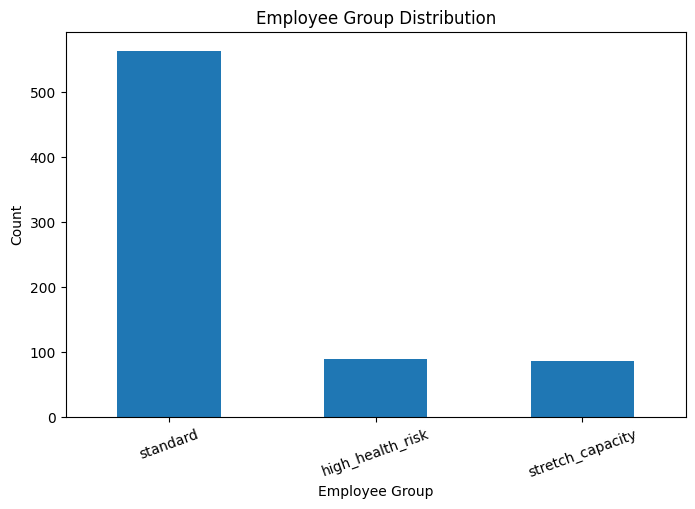

In [11]:
group_counts = df["employee_group"].value_counts()
print(group_counts)

plt.figure(figsize=(8,5))
group_counts.plot(kind="bar")
plt.title("Employee Group Distribution")
plt.xlabel("Employee Group")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

In [12]:
# compare the three groups on age, BMI, absenteeism, and a few work-related features

group_summary = df.groupby("employee_group")[["age", "body_mass_index", target_name, "work_load_average_day", "hit_target"]].mean()
group_summary

,age,body_mass_index,absenteeism_time_in_hours,work_load_average_day,hit_target
employee_group,,,,,
high_health_risk,47.393258,33.213483,5.943820,268.723247,93.696629
standard,35.909574,26.308511,7.909574,271.529271,94.648936
stretch_capacity,28.758621,22.379310,1.540230,274.067770,95.103448


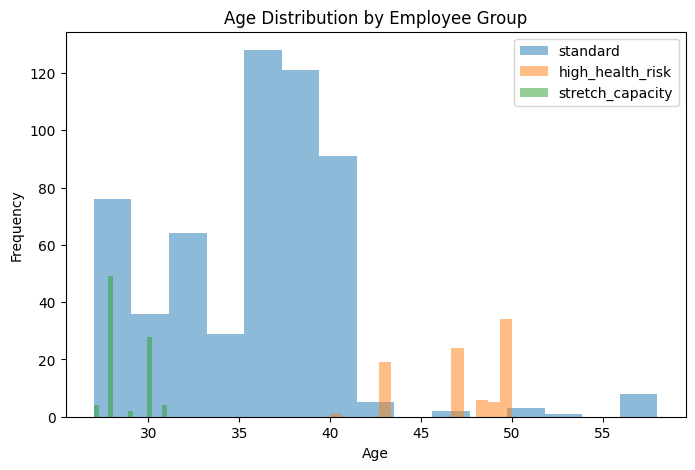

In [13]:
plt.figure(figsize=(8,5))
for group in df["employee_group"].unique():
    subset = df[df["employee_group"] == group]
    plt.hist(subset["age"], bins=15, alpha=0.5, label=group)

plt.title("Age Distribution by Employee Group")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.legend()
plt.show()

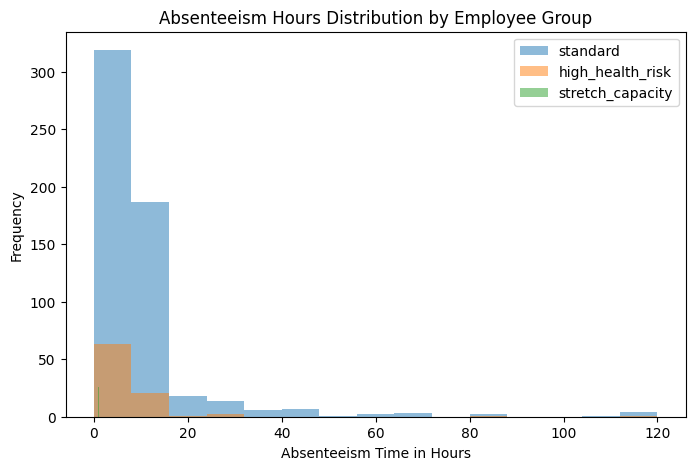

In [14]:
plt.figure(figsize=(8,5))
for group in df["employee_group"].unique():
    subset = df[df["employee_group"] == group]
    plt.hist(subset[target_name], bins=15, alpha=0.5, label=group)

plt.title("Absenteeism Hours Distribution by Employee Group")
plt.xlabel("Absenteeism Time in Hours")
plt.ylabel("Frequency")
plt.legend()
plt.show()

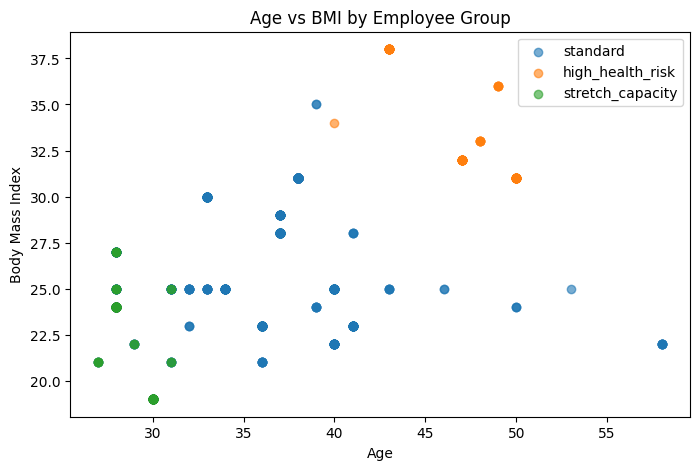

In [15]:
plt.figure(figsize=(8,5))
for group in df["employee_group"].unique():
    subset = df[df["employee_group"] == group]
    plt.scatter(subset["age"], subset["body_mass_index"], alpha=0.6, label=group)

plt.title("Age vs BMI by Employee Group")
plt.xlabel("Age")
plt.ylabel("Body Mass Index")
plt.legend()
plt.show()

In [16]:
# Check how the groups differ numerically

numeric_means = df.groupby("employee_group").mean(numeric_only=True).T
numeric_means.head(15)


employee_group,high_health_risk,standard,stretch_capacity
reason_for_absence,16.876404,19.317376,20.954023
month_of_absence,6.887640,6.326241,5.735632
day_of_the_week,3.820225,3.909574,4.045977
seasons,2.730337,2.500000,2.643678
transportation_expense,195.528090,225.161348,222.885057
distance_from_residence_to_work,20.786517,31.253546,28.160920
service_time,16.011236,12.687943,8.149425
age,47.393258,35.909574,28.758621
work_load_average_day,268.723247,271.529271,274.067770
hit_target,93.696629,94.648936,95.103448


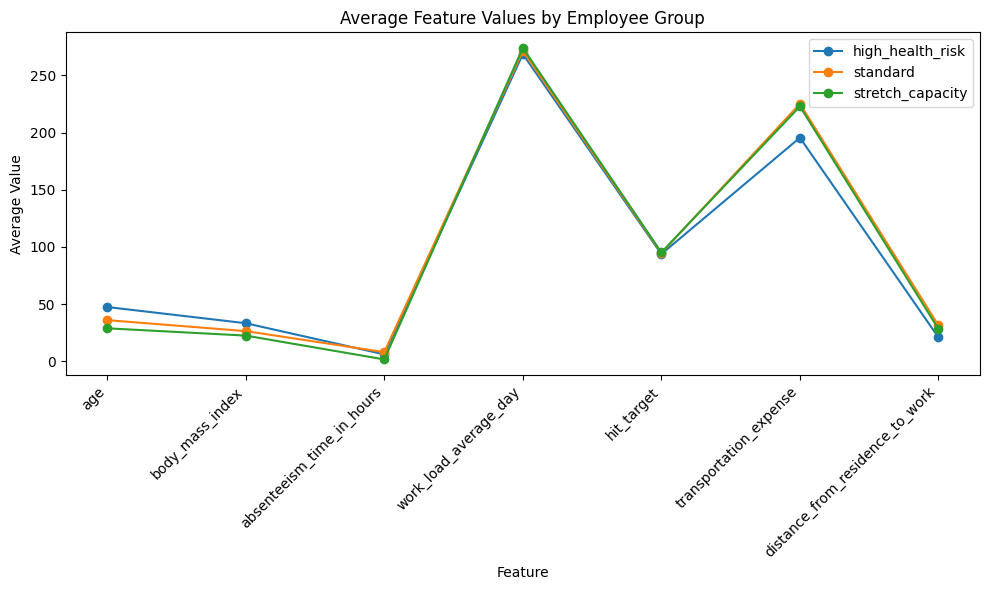

In [17]:
selected_features = ["age", "body_mass_index", target_name, "work_load_average_day", "hit_target", "transportation_expense", "distance_from_residence_to_work"]

available_features = [col for col in selected_features if col in df.columns]

plot_data = df.groupby("employee_group")[available_features].mean().T

plt.figure(figsize=(10,6))
for group in plot_data.columns:
    plt.plot(plot_data.index, plot_data[group], marker="o", label=group)

plt.title("Average Feature Values by Employee Group")
plt.xlabel("Feature")
plt.ylabel("Average Value")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()